# Baseline CNN — Cat Sound Classification

A from-scratch PyTorch CNN trained on log-mel spectrograms of cat vocalizations,
using the shared `kitty3000_ml` preprocessing pipeline and the fixed
`data/manifest.csv` train/val/test split. This is a first-pass baseline meant
to be iterated on, not a final model.

Spectrograms are saved into a cache directory inside data/ so taht kernel restarts do not need to rebuild them.


## Imports

In [19]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display, Audio

import librosa

from kitty3000_ml.labels import LABELS
from kitty3000_ml.preprocess import load_clip, logmel, SR, SECONDS, N_MELS

torch.manual_seed(42)

device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")


Using device: cuda


## Data Importing & Preprocessing

In [2]:
DATA_DIR = "../data/raw/CatSound_originals"

manifest = pd.read_csv("../data/manifest.csv")

train_df = manifest[manifest["split"] == "train"].reset_index(drop=True)
val_df = manifest[manifest["split"] == "val"].reset_index(drop=True)
test_df = manifest[manifest["split"] == "test"].reset_index(drop=True)

print(f"train: {len(train_df)}  val: {len(val_df)}  test: {len(test_df)}")

LABEL_TO_IDX = {name: i for i, name in enumerate(LABELS)}
IDX_TO_LABEL = {v: k for k, v in LABEL_TO_IDX.items()}


train: 2058  val: 448  test: 447


## Dataset Class

In [3]:
class CatSoundSpectrogramDataset(Dataset):
    """Wraps a manifest split as (log-mel spectrogram tensor, label index) pairs.
    Spectrograms are cached both in memory and on disk under cache_dir, so a
    kernel restart doesn't require re-decoding every mp3 from scratch."""

    def __init__(self, df, data_dir=DATA_DIR, cache_dir="../data/cache"):
        self.df = df.reset_index(drop=True)
        self.data_dir = data_dir
        self.cache_dir = cache_dir
        self._cache = {}

    def __len__(self):
        return len(self.df)

    def _cache_path(self, idx):
        row = self.df.iloc[idx]
        rel_path = os.path.splitext(row["path"])[0] + ".npy"
        return os.path.join(self.cache_dir, rel_path)

    def _load_mel(self, idx):
        if idx in self._cache:
            return self._cache[idx]

        cache_path = self._cache_path(idx)
        if os.path.exists(cache_path):
            mel = np.load(cache_path)
        else:
            row = self.df.iloc[idx]
            path = os.path.join(self.data_dir, row["path"])
            y = load_clip(path)
            mel = logmel(y)
            os.makedirs(os.path.dirname(cache_path), exist_ok=True)
            np.save(cache_path, mel)

        self._cache[idx] = mel
        return mel

    def __getitem__(self, idx):
        mel = self._load_mel(idx)
        mel = (mel - mel.mean()) / (mel.std() + 1e-6)
        x = torch.from_numpy(mel).unsqueeze(0).float()  # shape (1, N_MELS, frames)
        label = LABEL_TO_IDX[self.df.iloc[idx]["label"]]
        return x, label

    def preload(self, progress_widget=None):
        for i in range(len(self)):
            self._load_mel(i)
            if progress_widget is not None:
                progress_widget.value = i + 1


## Train, Test, Validate Datasets


In [4]:
train_ds = CatSoundSpectrogramDataset(train_df)
val_ds = CatSoundSpectrogramDataset(val_df)
test_ds = CatSoundSpectrogramDataset(test_df)

for name, ds in [("train", train_ds), ("val", val_ds), ("test", test_ds)]:
    progress = widgets.IntProgress(min=0, max=len(ds), description=f"{name}:")
    display(progress)
    ds.preload(progress)


IntProgress(value=0, description='train:', max=2058)

IntProgress(value=0, description='val:', max=448)

IntProgress(value=0, description='test:', max=447)

## Sanity Check Spectrogram

Sample tensor shape: torch.Size([1, 64, 688]), dtype: torch.float32, label: Angry


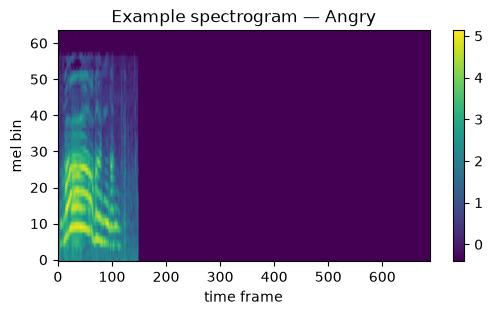

In [5]:
x, y = train_ds[0]
print(f"Sample tensor shape: {x.shape}, dtype: {x.dtype}, label: {IDX_TO_LABEL[y]}")

plt.figure(figsize=(6, 3))
plt.imshow(x[0].numpy(), origin="lower", aspect="auto")
plt.title(f"Example spectrogram — {IDX_TO_LABEL[y]}")
plt.xlabel("time frame")
plt.ylabel("mel bin")
plt.colorbar()
plt.show()

## DataLoaders

Groupg individual examples into batches for training. Only the training loader shuffles: val/test order doesn't matter and we want it stable so we can line predictions back up with val_df/test_df rows later.

In [6]:
BATCH_SIZE = 32

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


## CNN Architecture

In [7]:
class CNNBaseline(nn.Module):
    def __init__(self, n_classes=len(LABELS), dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.BatchNorm2d(16), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128, 64), nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


## Instantiate Model

In [8]:
model = CNNBaseline().to(device)
n_params = sum(p.numel() for p in model.parameters())

print(f"Model has {n_params:,} parameters")

Model has 106,538 parameters


## Loss, Optimizer & Hyperparameters

In [9]:
N_EPOCHS = 20
LR = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

os.makedirs("../models/cnn_baseline", exist_ok=True)
CHECKPOINT_PATH = "../models/cnn_baseline/cnn_baseline_best.pt"


## Training

In [10]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_macro_f1": []}
best_val_f1 = -1.0

for epoch in range(N_EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            val_loss += loss.item() * x.size(0)
            preds = logits.argmax(1)
            val_correct += (preds == y).sum().item()
            val_total += x.size(0)
            y_true.extend(y.cpu().tolist())
            y_pred.extend(preds.cpu().tolist())

    val_loss /= val_total
    val_acc = val_correct / val_total
    val_macro_f1 = f1_score(y_true, y_pred, average="macro")

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_macro_f1"].append(val_macro_f1)

    print(f"epoch {epoch+1}/{N_EPOCHS}  train_loss={train_loss:.3f}  "
          f"val_loss={val_loss:.3f}  val_acc={val_acc:.3f}  val_macro_f1={val_macro_f1:.3f}")

    if val_macro_f1 > best_val_f1:
        best_val_f1 = val_macro_f1
        torch.save(
            {"state_dict": model.state_dict(), "labels": LABELS,
             "val_macro_f1": val_macro_f1, "epoch": epoch},
            CHECKPOINT_PATH,
        )


print(f"Best val macro F1: {best_val_f1:.4f}")

epoch 1/20  train_loss=2.083  val_loss=1.893  val_acc=0.301  val_macro_f1=0.243
epoch 2/20  train_loss=1.777  val_loss=1.574  val_acc=0.462  val_macro_f1=0.434
epoch 3/20  train_loss=1.557  val_loss=2.046  val_acc=0.304  val_macro_f1=0.241
epoch 4/20  train_loss=1.391  val_loss=1.619  val_acc=0.422  val_macro_f1=0.381
epoch 5/20  train_loss=1.235  val_loss=2.259  val_acc=0.295  val_macro_f1=0.280
epoch 6/20  train_loss=1.187  val_loss=1.189  val_acc=0.571  val_macro_f1=0.533
epoch 7/20  train_loss=1.133  val_loss=1.565  val_acc=0.525  val_macro_f1=0.486
epoch 8/20  train_loss=1.075  val_loss=1.423  val_acc=0.480  val_macro_f1=0.446
epoch 9/20  train_loss=1.040  val_loss=1.168  val_acc=0.551  val_macro_f1=0.533
epoch 10/20  train_loss=0.970  val_loss=1.123  val_acc=0.594  val_macro_f1=0.584
epoch 11/20  train_loss=0.968  val_loss=1.348  val_acc=0.518  val_macro_f1=0.508
epoch 12/20  train_loss=0.932  val_loss=1.858  val_acc=0.429  val_macro_f1=0.378
epoch 13/20  train_loss=0.894  val_lo

## Testing / Verification

In [11]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint["state_dict"])
model.eval()

y_true, y_pred, y_prob = [], [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(1)
        y_true.extend(y.tolist())
        y_pred.extend(preds.cpu().tolist())
        y_prob.extend(probs.cpu().tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)


## Metrics

In [12]:
print(classification_report(y_true, y_pred, target_names=LABELS, zero_division=0))
print(f"Test macro F1: {f1_score(y_true, y_pred, average='macro'):.4f}")

              precision    recall  f1-score   support

       Angry       0.78      0.47      0.58        45
     Defence       0.84      0.84      0.84        44
    Fighting       0.70      0.87      0.77        45
       Happy       0.76      0.29      0.42        45
 HuntingMind       0.63      0.84      0.72        44
      Mating       0.64      0.71      0.67        45
  MotherCall       0.48      0.96      0.64        45
     Paining       0.38      0.41      0.40        44
     Resting       0.93      0.96      0.95        45
     Warning       0.83      0.22      0.35        45

    accuracy                           0.66       447
   macro avg       0.70      0.66      0.63       447
weighted avg       0.70      0.66      0.63       447

Test macro F1: 0.6341


## Analytics

### Training Curves

In [13]:
epochs = list(range(1, len(history["train_loss"]) + 1))

fig = go.Figure()
fig.add_trace(go.Scatter(x=epochs, y=history["train_loss"], name="train_loss"))
fig.add_trace(go.Scatter(x=epochs, y=history["val_loss"], name="val_loss"))
fig.add_trace(go.Scatter(x=epochs, y=history["val_macro_f1"], name="val_macro_f1", yaxis="y2"))
fig.update_layout(
    title="Training curves",
    xaxis_title="epoch",
    yaxis=dict(title="loss"),
    yaxis2=dict(title="macro F1", overlaying="y", side="right", range=[0, 1]),
    legend=dict(orientation="h"),
)

fig.show()


### Confusion Matrix

In [14]:
normalize_cb = widgets.Checkbox(value=False, description="Row-normalize")
cm_output = widgets.Output()

def render_confusion_matrix(change=None):
    cm = confusion_matrix(y_true, y_pred)
    if normalize_cb.value:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig = px.imshow(
        cm, x=LABELS, y=LABELS, text_auto=".2f" if normalize_cb.value else True,
        color_continuous_scale="Blues",
        labels=dict(x="Predicted", y="Actual", color="Count"),
        title="Confusion matrix",
    )
    with cm_output:
        cm_output.clear_output(wait=True)
        fig.show()

normalize_cb.observe(render_confusion_matrix, names="value")
display(normalize_cb, cm_output)
render_confusion_matrix()


Checkbox(value=False, description='Row-normalize')

Output()

### Per-class Precision, Recall, F1 bars

In [15]:
report = classification_report(y_true, y_pred, target_names=LABELS, output_dict=True, zero_division=0)

fig = go.Figure()
for metric in ["precision", "recall", "f1-score"]:
    fig.add_trace(go.Bar(name=metric, x=LABELS, y=[report[label][metric] for label in LABELS]))
fig.update_layout(barmode="group", title="Per-class precision / recall / F1", yaxis=dict(range=[0, 1]))
fig.show()


### Samples Browser

***Instructions:*** Pick a subset (a specific true class, or only the samples the model got wrong) and step through individual clips — listening to the audio, seeing its waveform and spectrogram, and seeing exactly what the model predicted. 

In [16]:
filter_dd = widgets.Dropdown(
    options=["All"] + LABELS + ["Misclassified only"],
    value="All",
    description="Filter:",
)
index_slider = widgets.IntSlider(min=0, max=0, description="Sample:")
browser_output = widgets.Output()

def get_filtered_indices():
    if filter_dd.value == "All":
        return list(range(len(test_df)))
    if filter_dd.value == "Misclassified only":
        return list(np.where(y_true != y_pred)[0])
    label_idx = LABEL_TO_IDX[filter_dd.value]
    return list(np.where(y_true == label_idx)[0])

def render_sample(change=None):
    indices = get_filtered_indices()
    if not indices:
        with browser_output:
            browser_output.clear_output(wait=True)
            print("No samples match this filter.")
        return
    index_slider.max = len(indices) - 1
    i = indices[min(index_slider.value, len(indices) - 1)]

    row = test_df.iloc[i]
    path = os.path.join(DATA_DIR, row["path"])
    waveform = load_clip(path)
    mel = test_ds._load_mel(i)

    with browser_output:
        browser_output.clear_output(wait=True)
        print(f"True: {IDX_TO_LABEL[y_true[i]]}   Predicted: {IDX_TO_LABEL[y_pred[i]]}")
        display(Audio(waveform, rate=SR))

        wave_fig = go.Figure(go.Scatter(y=waveform, mode="lines"))
        wave_fig.update_layout(title="Waveform", height=250)
        wave_fig.show()

        mel_fig = px.imshow(mel, origin="lower", aspect="auto", title="Log-mel spectrogram")
        mel_fig.show()

        prob_fig = go.Figure(go.Bar(x=LABELS, y=y_prob[i]))
        prob_fig.update_layout(title="Predicted probabilities", yaxis=dict(range=[0, 1]), height=300)
        prob_fig.show()

filter_dd.observe(render_sample, names="value")
index_slider.observe(render_sample, names="value")
display(filter_dd, index_slider, browser_output)
render_sample()


Dropdown(description='Filter:', options=('All', 'Angry', 'Defence', 'Fighting', 'Happy', 'HuntingMind', 'Matin…

IntSlider(value=0, description='Sample:', max=0)

Output()

### Duration Bias Sanity Ceheck

In [17]:
durations = [librosa.get_duration(path=os.path.join(DATA_DIR, p)) for p in test_df["path"]]
correct = (y_true == y_pred)

fig = px.box(
    x=[IDX_TO_LABEL[i] for i in y_true],
    y=durations,
    color=np.where(correct, "correct", "incorrect"),
    labels={"x": "True label", "y": "duration (s)", "color": "prediction"},
    title="Clip duration vs. classification outcome",
)
fig.show()


### UMAP Embedding Scatter

In [18]:
import umap

def extract_features(model, loader):
    model.eval()
    feats, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            f = model.features(x).flatten(1)  # (batch, 128)
            feats.append(f.cpu().numpy())
            labels.extend(y.tolist())
    return np.concatenate(feats), np.array(labels)

test_features, test_labels = extract_features(model, test_loader)
embedding_2d = umap.UMAP(n_components=2, random_state=42).fit_transform(test_features)

fig = px.scatter(
    x=embedding_2d[:, 0], y=embedding_2d[:, 1],
    color=[IDX_TO_LABEL[i] for i in test_labels],
    hover_name=[f"pred: {IDX_TO_LABEL[p]}" for p in y_pred],
    title="UMAP of learned features (test set)",
)
fig.show()


/home/cjk/code/CevenJKnowles/Kitty3000-ML/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
